# UT4 - Sesión 5: Binarización Avanzada y Morfología
**Módulo:** Programación de Inteligencia Artificial
**Unidad:** Tratamiento de Imagen

---

### Objetivos de la Sesión
1.  Entender por qué el umbral fijo (`127`) falla en imágenes reales.
2.  Aplicar el **Método de Otsu** para calcular umbrales automáticamente.
3.  Utilizar la **Morfología Matemática** (Erosión, Dilatación, Apertura, Cierre).
4.  Implementar el **Pipeline de Segmentación** completo corregido (invirtiendo colores).

In [4]:
# CONFIGURACIÓN INICIAL (Ejecuta esto primero)
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración de tamaño de gráficos
plt.rcParams['figure.figsize'] = (10.0, 6.0)
plt.rcParams['image.cmap'] = 'gray'

def mostrar_comparativa(img_original, img_procesada, titulo1="Original", titulo2="Resultado"):
    """Función auxiliar para mostrar dos imágenes lado a lado"""
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_procesada, cmap='gray')
    plt.title(titulo2)
    plt.axis('off')
    plt.show()

---

## EJERCICIO 1: La limitación del ojo humano (Otsu)

Tienes una imagen (`Manuscritos.jpg`) de un texto antiguo. El papel no es blanco puro (es amarillento/oscuro) y la tinta varía de intensidad.

**Tu misión:**
1. Intentar aislar el texto usando un umbral fijo manual (ej. 127). Verás que o pierdes texto o coges mucha mancha.
2. Dejar que el algoritmo de **Otsu** calcule el corte estadístico ideal entre el papel y la tinta.

**Pistas:**
* Carga la imagen en escala de grises.
* Para Otsu, el valor de umbral inicial se pone a 0, pero se añade la flag `cv2.THRESH_OTSU`.
* **Nota:** En este paso no te preocupes si el fondo sale blanco y las letras negras, solo queremos ver cómo Otsu separa las clases.

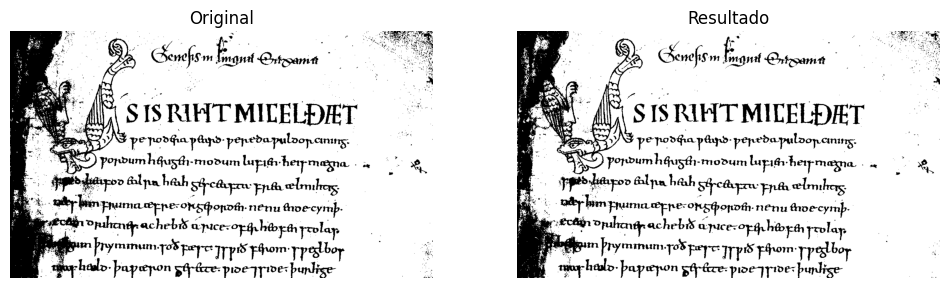

El umbral calculado por Otsu fue: 121.0


In [ ]:
# 1. Cargar imagen en escala de grises
img_manuscrito = cv2.imread("imagenes/Manuscritos.jpg")
img_manuscrito_grises = cv2.cvtColor(img_manuscrito, cv2.COLOR_BGR2GRAY)
# 2. Umbralizado Manual (Global)
# Usa cv2.threshold con valor 127. Guarda el resultado en 'thresh_manual'
thresh_manual = cv2.threshold(img_manuscrito_grises, 127, 255, cv2.THRESH_BINARY)
# 3. Umbralizado de Otsu
# Usa cv2.threshold con flag THRESH_OTSU. Guarda el resultado en 'thresh_otsu'
thresh_otsu = cv2.threshold(img_manuscrito_grises, 0, 255, cv2.THRESH_OTSU)
# 4. Visualización
# Usa mostrar_comparativa() para ver manual vs otsu
# print(f"El umbral calculado por Otsu fue: {ret}") # Imprime el valor 'ret' para ver qué decidió Otsu
mostrar_comparativa(thresh_manual[1], thresh_otsu[1])
print(f"El umbral calculado por Otsu fue: {thresh_otsu[0]}")

---

## EJERCICIO 2: Taller de Morfología (Mecánica)

Carga la imagen `Rauschbild-30.png` (el dibujo de la cara). Tiene ruido tipo "sal y pimienta".

**EL TRUCO (Muy Importante):**
En OpenCV, las operaciones de morfología actúan sobre el color **BLANCO**. 
Como este dibujo tiene trazos NEGROS sobre fondo blanco, si aplicas "Erosión" directamente, el fondo blanco se comerá a la línea negra y el dibujo se hará más gordo (lo contrario a lo que dice la intuición).

**Tu misión:**
1. Cargar la imagen.
2. **INVERTIRLA** (`cv2.bitwise_not`) para que los trazos sean BLANCOS.
3. Probar las 4 operaciones.

**Objetivos Visuales:**
* **Erode:** Las líneas del dibujo deben volverse finas.
* **Dilate:** Las líneas deben volverse gruesas.
* **Opening:** Debe quitar el ruido (puntitos) del fondo.
* **Closing:** Debe cerrar huecos dentro de los trazos del dibujo.

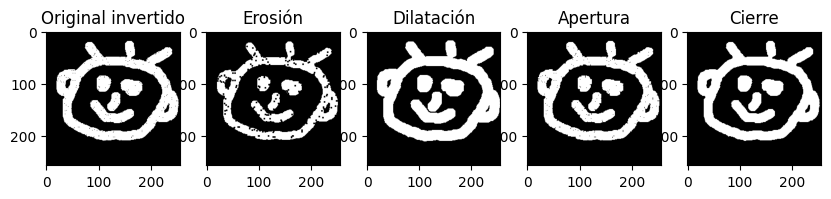

In [12]:
# 1. Cargar imagen
# Carga 'Rauschbild-30.png' en grises
img_rauschbild = cv2.imread("imagenes/Rauschbild-30.png")
img_rauschbild_gris = cv2.cvtColor(img_rauschbild, cv2.COLOR_BGR2GRAY)
# 2. INVERSIÓN (Vital para que la lógica funcione)
# Crea 'img_inv' usando cv2.bitwise_not(img_original)
img_inv = cv2.bitwise_not(img_rauschbild_gris)
# 3. Definir el Kernel
# Crea una matriz de unos de 3x3 o 5x5 (np.ones)
kernel = np.ones([3, 3])
# 4. Aplicar Operaciones sobre la imagen INVERTIDA ('img_inv')
# Aplica Erosión
img_erosion = cv2.erode(img_inv, kernel)
# Aplica Dilatación
img_dilatacion = cv2.dilate(img_inv, kernel)
# Aplica Apertura (Opening)
img_open = cv2.morphologyEx(img_inv, cv2.MORPH_OPEN, kernel)
# Aplica Cierre (Closing)
img_close = cv2.morphologyEx(img_inv, cv2.MORPH_CLOSE, kernel)

# 5. Mostrar resultados
# Puedes usar subplots. Recuerda que verás el dibujo en blanco sobre negro (como una radiografía).
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5)
ax1.imshow(img_inv, cmap='gray'); ax1.set_title("Original invertido")
ax2.imshow(img_erosion); ax2.set_title("Erosión")
ax3.imshow(img_dilatacion); ax3.set_title("Dilatación")
ax4.imshow(img_open); ax4.set_title("Apertura")
ax5.imshow(img_close); ax5.set_title("Cierre")
plt.show()

---

## EJERCICIO 3: El Archivista (Pipeline Completo)

Volvemos al manuscrito: `Manuscritos.jpg`.

**Tu misión:** Obtener una máscara binaria donde las **LETRAS SEAN BLANCAS** y el fondo negro, sin ruido de manchas.

**El Pipeline (Receta Maestra):**
1.  **Escala de Grises**.
2.  **Suavizado (Blur)**: Aplica un `GaussianBlur` suave (ej. 5x5) para reducir el ruido del papel.
3.  **Binarización (Otsu Invertido)**: 
    * Como queremos letras blancas, usa: `cv2.threshold(..., ..., cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)`.
4.  **Limpieza (Morfología)**:
    * Observa el resultado. ¿Quedan puntitos del papel texturizado? -> Usa **Opening**.
    * ¿Las letras antiguas están rotas? -> Usa **Closing** para unirlas un poco.

**Pistas:**
* El tamaño del kernel es clave. Las letras manuscritas son finas; si usas un kernel muy grande (7x7) en el Opening, borrarás las letras.

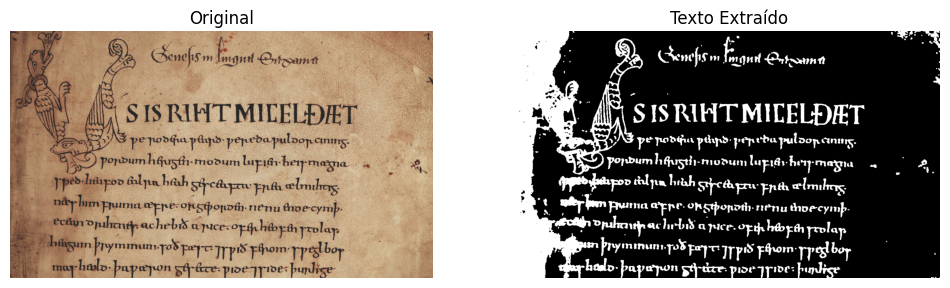

In [23]:
# Implementa aquí tu Pipeline completo

# 1. Carga
img_manuscrito = cv2.imread("imagenes/Manuscritos.jpg")
img_manuscrito_rgb = cv2.cvtColor(img_manuscrito, cv2.COLOR_BGR2RGB)
img_manuscrito_grises = cv2.cvtColor(img_manuscrito, cv2.COLOR_BGR2GRAY)
# 2. Blur (Pre-procesamiento)
img_manuscrito_blur = cv2.GaussianBlur(img_manuscrito_grises, (5,5), 0)
# 3. Otsu INV (Segmentación)
# Recuerda usar THRESH_BINARY_INV
img_manuscrito_thresh = cv2.threshold(img_manuscrito_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# 4. Morfología (Post-procesamiento)
# Prueba primero con un kernel pequeño (3,3)
kernel = np.ones([3,3])
img_manuscrito_open = cv2.morphologyEx(img_manuscrito_thresh[1], cv2.MORPH_OPEN, kernel)
# 5. Resultado Final
# mostrar_comparativa(img_original, mascara_final, "Original", "Texto Extraído")
mostrar_comparativa(img_manuscrito_rgb, img_manuscrito_open, "Original", "Texto Extraído")